# Withdrawal finality: a first look with pandas

This is a personal data-science practice notebook, not part of the thesis. The data comes from
`l1/scripts/generate_sample_data.js`, which ran 20 real deposit-wait-claim cycles per architecture
against the actual `WithdrawalEscrow` contracts on a live local Hardhat chain (no mocking) and
recorded the results to `data/withdrawal_samples.csv`.

Goal: get comfortable with the basic pandas workflow — load, inspect, group, plot — using data
we generated ourselves and already understand.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/withdrawal_samples.csv")
df.head()

,run,architecture,commitment_id,deposit_amount_eth,submit_block,deposit_block,claim_block,blocks_to_unlock,deposit_gas,claim_gas
0,0,ZK,28,0.2419,448,449,454,4,70467,66282
1,0,Optimistic,25,0.1611,455,456,466,9,70467,81403
2,1,ZK,29,0.4110,467,468,473,4,70467,66282
3,1,Optimistic,26,0.2004,474,475,485,9,70467,81403
4,2,ZK,30,0.4992,486,487,492,4,70467,66282


## First look

`.info()` tells you the column types and whether anything is missing (null). `.describe()` gives
quick summary statistics for the numeric columns — useful as a sanity check before you trust
anything else you compute.

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   run                 200 non-null    int64  
 1   architecture        200 non-null    str    
 2   commitment_id       200 non-null    int64  
 3   deposit_amount_eth  200 non-null    float64
 4   submit_block        200 non-null    int64  
 5   deposit_block       200 non-null    int64  
 6   claim_block         200 non-null    int64  
 7   blocks_to_unlock    200 non-null    int64  
 8   deposit_gas         200 non-null    int64  
 9   claim_gas           200 non-null    int64  
dtypes: float64(1), int64(8), str(1)
memory usage: 15.8 KB


In [3]:
df.describe()

,run,commitment_id,deposit_amount_eth,submit_block,deposit_block,claim_block,blocks_to_unlock,deposit_gas,claim_gas
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.0,200.000000
mean,49.500000,76.000000,0.261383,1392.000000,1393.000000,1400.500000,6.500000,70467.0,73842.500000
std,28.938507,28.977552,0.142932,549.842828,549.842828,549.864533,2.506274,0.0,7579.472426
min,0.000000,25.000000,0.010000,448.000000,449.000000,454.000000,4.000000,70467.0,66282.000000
25%,24.750000,51.000000,0.143475,920.000000,921.000000,927.250000,4.000000,70467.0,66282.000000
50%,49.500000,76.000000,0.246650,1392.000000,1393.000000,1400.500000,6.500000,70467.0,73842.500000
75%,74.250000,101.000000,0.400600,1864.000000,1865.000000,1873.750000,9.000000,70467.0,81403.000000
max,99.000000,127.000000,0.499200,2336.000000,2337.000000,2347.000000,9.000000,70467.0,81403.000000


## Grouping by architecture

`groupby()` is the pandas workhorse: split the rows into groups (here, ZK vs Optimistic), then
compute something per group. `.agg(["mean", "std"])` gets both the average and the spread in one call.

In [4]:
summary = df.groupby("architecture")[["blocks_to_unlock", "deposit_gas", "claim_gas"]].agg(["mean", "std"])
summary

blocks_to_unlock      deposit_gas      claim_gas     
                         mean  std        mean  std      mean  std
architecture                                                      
Optimistic                9.0  0.0     70467.0  0.0   81403.0  0.0
ZK                        4.0  0.0     70467.0  0.0   66282.0  0.0

## Why the standard deviation is exactly zero

Notice `std` is `0.0` for `blocks_to_unlock` in both groups — every ZK sample needed exactly 4
blocks, every Optimistic sample needed exactly 9. That is not a bug in the data; it is a real
property of how the script runs. Hardhat's network only advances a block when a transaction
happens (no wall-clock mining), and the script always submits a commitment and deposits against
it back-to-back with nothing else interleaved. That fixes the gap between "commitment submitted"
and "deposit landed" at exactly one block, every single run — so the block count to reach each
verifier's fixed window (5 blocks for ZK, 10 for Optimistic) comes out identical every time.

A good follow-up experiment: interleave a random number of unrelated transactions between submit
and deposit in the generator script, and see this column develop real variance.

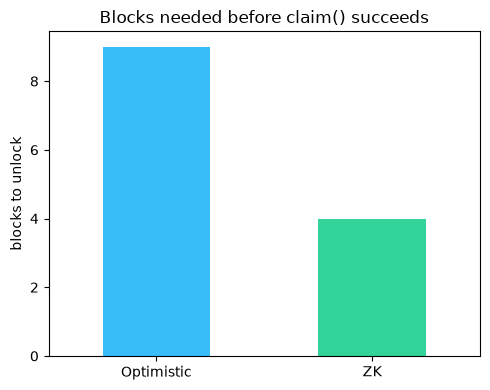

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
summary["blocks_to_unlock"]["mean"].plot(kind="bar", ax=ax, color=["#38bdf8", "#34d399"])
ax.set_ylabel("blocks to unlock")
ax.set_title("Blocks needed before claim() succeeds")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Gas cost: does it depend on how much you deposit?

Intuition check before computing anything: an EVM `SSTORE`/`SLOAD` costs the same gas regardless
of the numeric value being stored. `deposit()` and `claim()` do not loop over the amount or do
anything proportional to it, so gas should be flat no matter what you deposit. Let's verify that
with a correlation coefficient instead of just asserting it.

In [6]:
corr = df["deposit_amount_eth"].corr(df["claim_gas"])
print(f"correlation between deposit amount and claim gas: {corr:.4f}")

correlation between deposit amount and claim gas: 0.0185


A correlation near 0 confirms the intuition: deposit size and gas cost are unrelated here. If you
ever see a strong correlation between a value amount and gas cost in a real contract, that is a
sign the function is doing per-unit work (e.g. looping over an array sized by the input),
which is worth a second look for a potential denial-of-service vector.

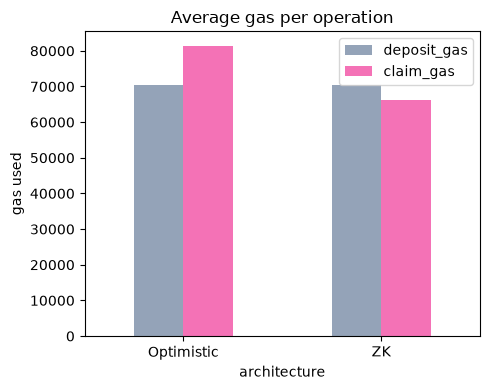

In [7]:
gas_summary = df.groupby("architecture")[["deposit_gas", "claim_gas"]].mean()
gas_summary.plot(kind="bar", figsize=(5, 4), color=["#94a3b8", "#f472b6"])
plt.ylabel("gas used")
plt.title("Average gas per operation")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Where to take this next

- Rerun `generate_sample_data.js` with `SAMPLE_RUNS=100` for a bigger sample.
- Modify the generator to interleave random extra transactions between submit and deposit, then
  redo the `blocks_to_unlock` groupby — you should see real variance and get to practice
  histograms instead of just bar charts of the mean.
- Try `df.corr(numeric_only=True)` for a full correlation matrix across every numeric column at once.